In [3]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

eda

In [4]:
# 2. Load dataset
df = pd.read_csv("insurance.csv")

In [5]:
# 3. First 5 rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
# 11. Unique values in categorical columns
for col in ["sex", "smoker", "region"]:
    print(col, df[col].unique())

sex <StringArray>
['female', 'male']
Length: 2, dtype: str
smoker <StringArray>
['yes', 'no']
Length: 2, dtype: str
region <StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


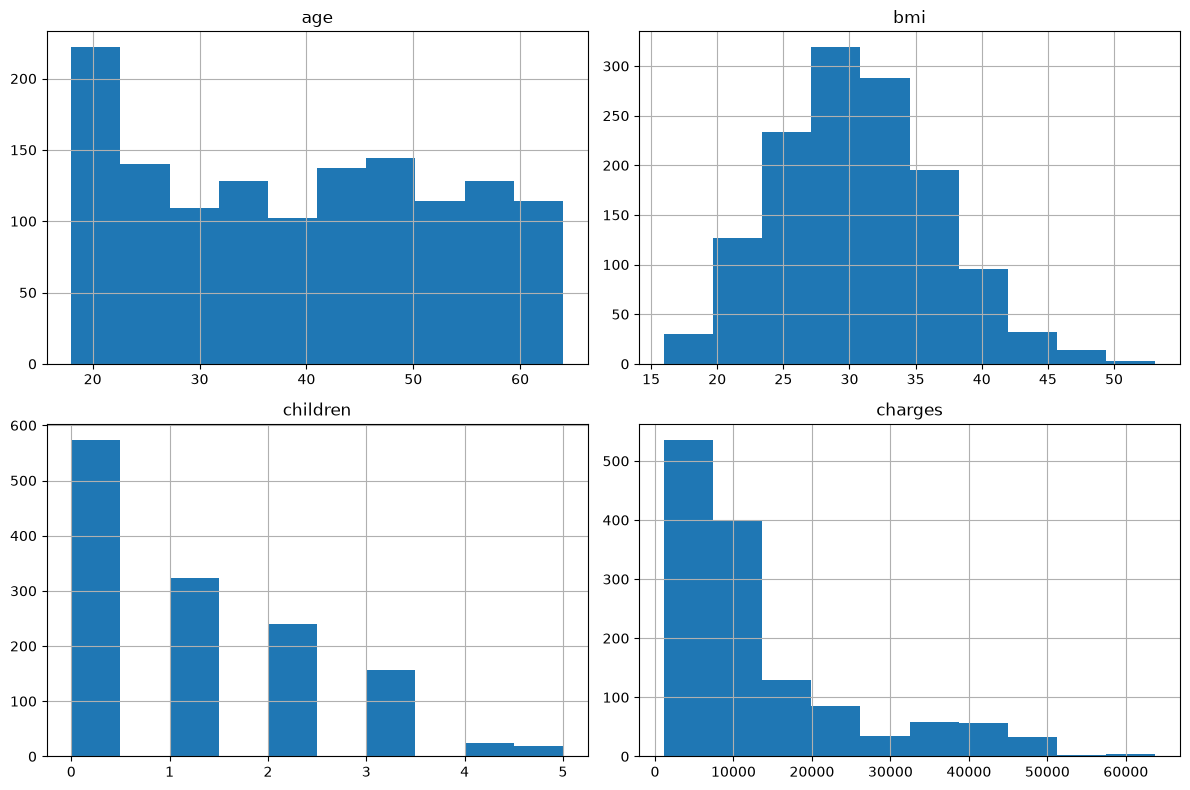

In [7]:
# 13. Distribution of numerical features
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

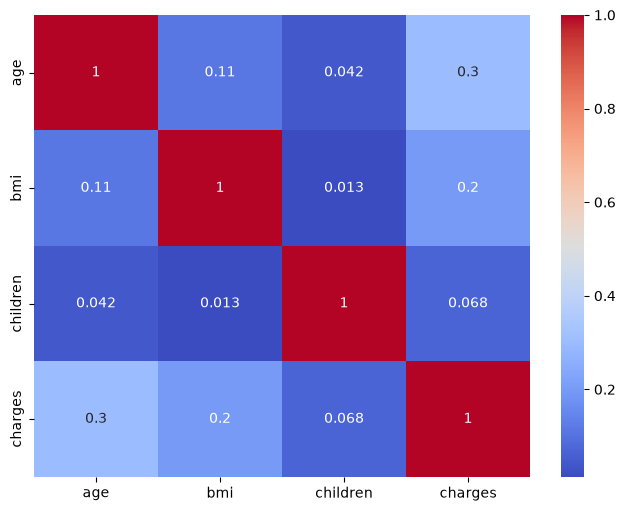

In [8]:
# 14. Correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.show()

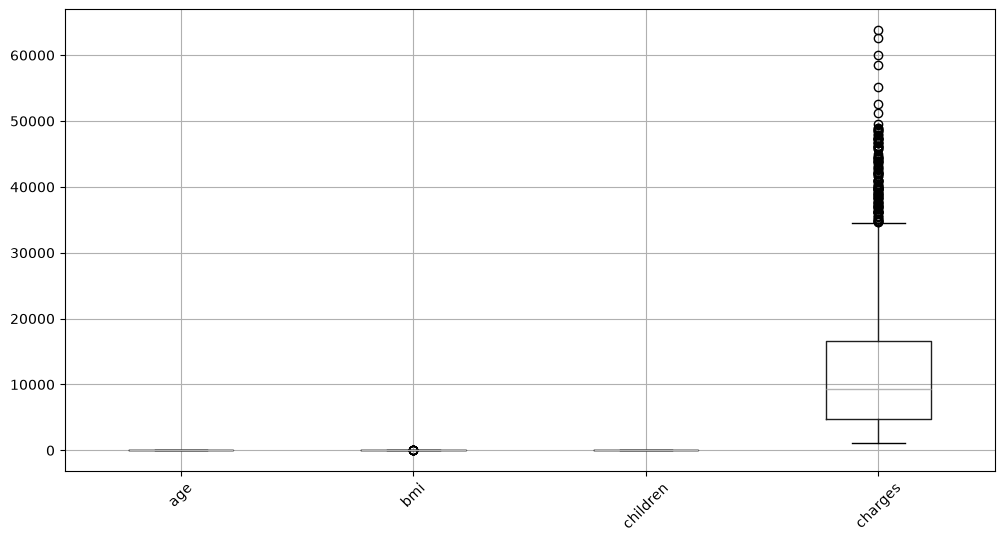

In [9]:
# 15. Boxplots for numerical columns
plt.figure(figsize=(12, 6))
df.select_dtypes(include="number").boxplot()
plt.xticks(rotation=45)
plt.show()

data cleaning and preprocessing

In [10]:
df_cleaned = df.copy()
df_cleaned.drop_duplicates(inplace=True)

In [11]:
# 16. Map categorical columns to numerical values
# print(df_cleaned)
print(df_cleaned['sex'].value_counts())
print(df_cleaned['smoker'].value_counts())
df_cleaned['sex']= df_cleaned['sex'].map({"male":0,"female":1})
df_cleaned['smoker']= df_cleaned['smoker'].map({"yes":1,"no":0})
print(df_cleaned['sex'].unique())

sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
[1 0]


In [12]:
# rename columns
df_cleaned.rename(columns={"sex": "is_female", "smoker": "is_smoker"}, inplace=True)
# modify region column to be one-hot encoded
df_cleaned = pd.get_dummies(df_cleaned, columns=["region"], drop_first=True)

In [13]:
df_cleaned = df_cleaned.astype(int)
df_cleaned.info()
print(df_cleaned.head())

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               1337 non-null   int64
 1   is_female         1337 non-null   int64
 2   bmi               1337 non-null   int64
 3   children          1337 non-null   int64
 4   is_smoker         1337 non-null   int64
 5   charges           1337 non-null   int64
 6   region_northwest  1337 non-null   int64
 7   region_southeast  1337 non-null   int64
 8   region_southwest  1337 non-null   int64
dtypes: int64(9)
memory usage: 104.5 KB
   age  is_female  bmi  children  is_smoker  charges  region_northwest  \
0   19          1   27         0          1    16884                 0   
1   18          0   33         1          0     1725                 0   
2   28          0   33         3          0     4449                 0   
3   33          0   22         0          0    21984                 1   
4   3

feature engineering and extraction

<Axes: xlabel='bmi', ylabel='Count'>

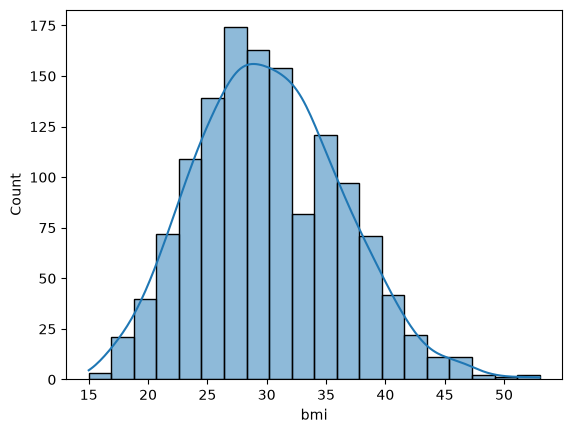

In [14]:
sns.histplot(df_cleaned['bmi'], bins=20, kde=True)

In [15]:
df_cleaned['bmi_category'] = pd.cut(df_cleaned['bmi'], bins=[0, 18.5, 24.9, 29.9, np.inf], labels=['Underweight', 'Normal weight', 'Overweight', 'Obesity'])

In [16]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   age               1337 non-null   int64   
 1   is_female         1337 non-null   int64   
 2   bmi               1337 non-null   int64   
 3   children          1337 non-null   int64   
 4   is_smoker         1337 non-null   int64   
 5   charges           1337 non-null   int64   
 6   region_northwest  1337 non-null   int64   
 7   region_southeast  1337 non-null   int64   
 8   region_southwest  1337 non-null   int64   
 9   bmi_category      1337 non-null   category
dtypes: category(1), int64(9)
memory usage: 106.0 KB


In [17]:
df_cleaned= pd.get_dummies(df_cleaned,columns=["bmi_category"], drop_first=True)

In [18]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obesity
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,False,False,True
1334,18,1,31,0,0,2205,0,0,0,False,False,True
1335,18,1,36,0,0,1629,0,1,0,False,False,True
1336,21,1,25,0,0,2007,0,0,1,False,True,False


In [19]:
df_cleaned=df_cleaned.astype(int)

In [20]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obesity
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


feature scaling

In [21]:
from sklearn.preprocessing import StandardScaler
cols=['age', 'bmi', 'children']
scaler= StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [22]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obesity
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [23]:
from scipy.stats import pearsonr

# cols to check correlation with 'charges'
cols_to_check = ['age', 'bmi', 'children', 'is_female', 'is_smoker', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_Normal weight', 'bmi_category_Overweight', 'bmi_category_Obesity']

correlations = {}
for col in cols_to_check:
    corr, _ = pearsonr(df_cleaned[col], df_cleaned['charges'])
    correlations[col] = corr

# print(correlations)

# covert in dataframe
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Correlation_with_charges'])
correlation_df = correlation_df.sort_values(by='Correlation_with_charges', ascending=False)
print(correlation_df)

                       Feature  Correlation_with_charges
4                    is_smoker                  0.787234
0                          age                  0.298309
10        bmi_category_Obesity                  0.200348
1                          bmi                  0.196236
6             region_southeast                  0.073577
2                     children                  0.067390
5             region_northwest                 -0.038695
7             region_southwest                 -0.043637
3                    is_female                 -0.058046
8   bmi_category_Normal weight                 -0.104042
9      bmi_category_Overweight                 -0.120601


In [ ]:
# apply chi-square test for categorical features
from scipy.stats import chi2_contingency
alpha = 0.05
df_cleaned['charges'] = pd.cut(df_cleaned['charges'], bins=[0, 10000, 20000, 30000, 40000, 50000, np.inf], labels=['0-10k', '10k-20k', '20k-30k', '30k-40k', '40k-50k', '50k+'])
chi2_results = {}
for col in ['is_female', 'is_smoker', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_Normal weight', 'bmi_category_Overweight', 'bmi_category_Obesity']:
    contingency_table = pd.crosstab(df_cleaned[col], df_cleaned['charges'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"Chi-square test for {col}: p-value = {p}")
    chi2_results[col] = {
    "chi2": chi2, "p-value": p,
    "decision": "Reject null hypothesis" if p < alpha else "Fail to reject null hypothesis",
    }


chi2_results_df = pd.DataFrame.from_dict(chi2_results, orient='index')
chi2_results_df.reset_index(inplace=True)


Chi-square test for is_female: p-value = 0.00806554470816911
Chi-square test for is_smoker: p-value = 1.0743783755761315e-170
Chi-square test for region_northwest: p-value = 0.3625146468425866
Chi-square test for region_southeast: p-value = 0.003182829094415274
Chi-square test for region_southwest: p-value = 0.24712706227778075
Chi-square test for bmi_category_Normal weight: p-value = 7.458260058328136e-07
Chi-square test for bmi_category_Overweight: p-value = 1.861321039466813e-12
Chi-square test for bmi_category_Obesity: p-value = 7.887066916733796e-29
